# Parte 5 · Regularización y generalización

**Lo que pide el enunciado (§9) y dónde está:**

| Pide | Dónde |
|---|---|
| 9.1 Dropout, Weight Decay, Batch Normalization | ablación A1–A5 (§2–3) |
| 9.2 Data Augmentation con sentido para el problema, y si altera rasgos diagnósticos | §1 (y figura en `p1_exploracion` §6) |
| 9.3 Early Stopping: métrica, paciencia, criterio de mejora, recuperación del mejor modelo | §1 |
| 9.4 Ablation study | §2–3 |

Código: BN y dropout en `modelos.crear_modelo`, aumento en `datos.AumentoGPU`, weight decay en
`entrenamiento.crear_optimizador`, early stopping en `entrenamiento.entrenar`.

In [1]:
from analisis import *          # cargar resultados, tablas, curvas (ver analisis.py)
R = resultados()
print("terminados:", " ".join(R))

terminados: E01 E02 E03 E04 E05 E06 E07 E08 E09 E10 E11 E12 A1 A2 A3 A4 A5 A6 T1 T2 T3 T4 L2 L3 L4 L5


## 1. Técnicas y cómo se implementaron

**Data augmentation** (tres niveles, en GPU):

| Nivel | Transformaciones |
|---|---|
| `ninguno` | recorte central 128 px (igual que en validación) |
| `basico` | recorte aleatorio de 128 px dentro de 144 + flip horizontal |
| `fuerte` | Random Resized Crop (escala 0,35–1) + flip + color jitter suave (brillo, contraste, saturación ±20 %, **sin tono**) + Random Erasing (p = 0,25) |

¿Alteran rasgos diagnósticos? **Sí, algunas podrían:** el cambio de tono cambiaría especies que se
distinguen por color (por eso se excluyó); el flip horizontal invierte la quiralidad de las conchas de
caracol, y en ese caso el flip "miente"; un recorte agresivo o el *erasing* pueden eliminar justo la parte
diagnóstica (la cola de un ave, la flor de una planta). Se evitaron el flip vertical y las rotaciones
grandes, porque las fotos tienen orientación natural.

**Early stopping** (en todos los experimentos del proyecto):

| | |
|---|---|
| Métrica | top-1 de validación |
| Paciencia | 4 épocas sin mejora |
| Criterio de mejora | superar al mejor valor en más de 0,1 pp (`min_delta = 0.001`) |
| Recuperación | en cada mejora se guarda `mejor.pt`; al terminar se recargan esos pesos y con ellos se hace la evaluación final |

**Dropout:** p = 0,3 antes de la capa final. **Weight decay:** 5e-5 (L2 en SGD, sin aplicarlo a sesgos ni a
BN). **BatchNorm:** en la ablación A1 cada BN de la ResNet se sustituye por la identidad.

## 2. Definición de la ablación: un componente cada vez

In [2]:
definiciones([("A1", "E03"), ("A2", "A1"), ("A3", "A2"), ("A4", "A3"), ("A5", "A4"), ("A6", "A2"), ("E03", "A6")])

,referencia,descripción,estado,cambios
ID,,,,
A1,E03,"sin BN, sin dropout, sin aumento, sin wd",terminado,bn: True → False; aumento: basico → ninguno; w...
A2,A1,+ BatchNorm,terminado,bn: False → True
A3,A2,+ BN + Dropout 0.3,terminado,dropout: 0.0 → 0.3
A4,A3,+ BN + Dropout + aumento fuerte,terminado,aumento: ninguno → fuerte
A5,A4,+ BN + Dropout + aumento fuerte + wd 5e-5,terminado,weight_decay: 0.0 → 5e-05
A6,A2,"BN + aumento básico (sin dropout, sin wd)",terminado,aumento: ninguno → basico
E03,A6,ResNet-18 desde cero (receta base),terminado,weight_decay: 0.0 → 5e-05


## 3. Resultados

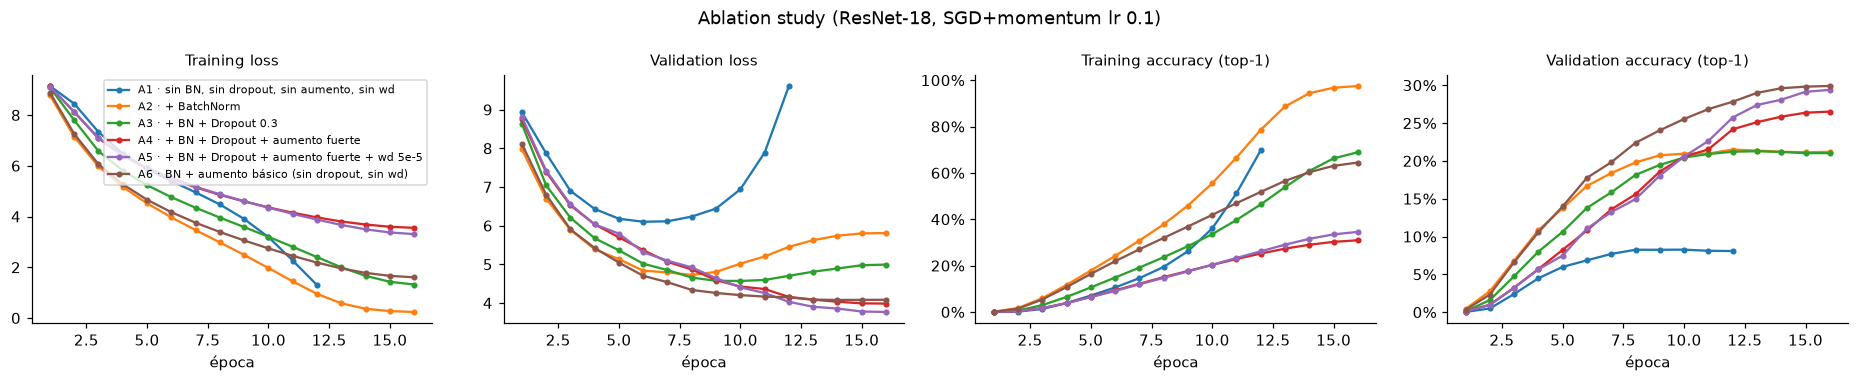

,descripción,top1,Δ top-1 vs anterior,top5,f1_macro,train_top1,brecha_top1,val loss mín.,época val loss mín.,mejor_ep,épocas
ID,,,,,,,,,,,
A1,"sin BN, sin dropout, sin aumento, sin wd",8.3%,,20.3%,7.4%,36.0%,27.8%,6.10,6,10,12
A2,+ BatchNorm,21.5%,+13.2%,41.2%,21.2%,78.6%,57.1%,4.72,8,12,16
A3,+ BN + Dropout 0.3,21.2%,-0.3%,41.4%,20.5%,53.9%,32.7%,4.57,10,13,16
A4,+ BN + Dropout + aumento fuerte,26.5%,+5.3%,48.0%,25.4%,30.9%,4.4%,3.99,16,16,16
A5,+ BN + Dropout + aumento fuerte + wd 5e-5,29.4%,+2.9%,51.5%,28.3%,34.6%,5.2%,3.77,16,16,16
A6,"BN + aumento básico (sin dropout, sin wd)",29.8%,+0.4%,51.6%,29.2%,64.5%,34.6%,4.08,14,16,16
E03,ResNet-18 desde cero (receta base),32.4%,+2.5%,54.5%,31.8%,69.6%,37.2%,3.82,16,16,16


In [3]:
curvas(R, ["A1", "A2", "A3", "A4", "A5", "A6"], "Ablation study (ResNet-18, SGD+momentum lr 0.1)")
t = tabla(R, ["A1", "A2", "A3", "A4", "A5", "A6", "E03"])
if len(t):
    t["Δ top-1 vs anterior"] = t.top1.diff()
    t["val loss mín."] = [R[i]["hist"].val_loss.min() for i in t.index]
    t["época val loss mín."] = [int(R[i]["hist"].val_loss.idxmin()) + 1 for i in t.index]
t[["descripción", "top1", "Δ top-1 vs anterior", "top5", "f1_macro", "train_top1", "brecha_top1",
   "val loss mín.", "época val loss mín.", "mejor_ep", "épocas"]].style.format(
    FMT | {"Δ top-1 vs anterior": "{:+.1%}", "val loss mín.": "{:.2f}"}, na_rep="") if len(t) else None

**Tabla de la ablación** (formato del enunciado):

| Exp | BatchNorm | Dropout | Aumento | Weight decay | Top-1 | Train top-1 |
|---|---|---|---|---|---|---|
| A1 | No | No | No | No | 8,3 % | 36,0 % |
| A2 | Sí | No | No | No | 21,5 % | 78,6 % |
| A3 | Sí | Sí | No | No | 21,2 % | 53,9 % |
| A4 | Sí | Sí | fuerte | No | 26,5 % | 30,9 % |
| A5 | Sí | Sí | fuerte | Sí | 29,4 % | 34,6 % |
| A6 | Sí | No | básico | No | 29,8 % | 64,5 % |
| E03 | Sí | No | básico | Sí | **32,4 %** | 69,6 % |

**Lectura:**

* **BatchNorm es, con diferencia, lo que más aporta (+13,2 pp).** Sin BN, la ResNet-18 no diverge (el
  recorte del gradiente la contiene), pero aprende muy despacio: 8,3 %, y early stopping la detuvo en la
  época 12. BN mantiene las activaciones en una escala estable capa a capa, lo que permite un lr de 0,1.
  Su efecto es sobre todo de **optimización**, más que de regularización.
* **Sin aumento, la red memoriza:** A2 llega a 78,6 % en train y 21,5 % en val. Su val loss es mínima en
  la época 8 y luego sube, aunque el top-1 se mantiene: el modelo se vuelve demasiado confiado en sus
  errores.
* **Dropout (A2→A3): 0 pp de top-1**, pero baja el train top-1 de 79 % a 54 % y mejora la val loss
  (4,57 frente a 4,72). Reduce la sobreconfianza, pero no mejora el acierto.
* **El aumento es el segundo factor más importante:** +5,3 pp el fuerte (A3→A4) y +8,3 pp el básico
  (A2→A6). Con aumento fuerte la brecha train–val casi desaparece (30,9 % frente a 26,5 %), y la curva
  sigue subiendo en la época 16: **la red está infraentrenada**, porque la tarea de entrenamiento se volvió
  más difícil. Con este presupuesto de 16 épocas, **el básico rinde más que el fuerte + dropout**. Con más
  épocas, el fuerte probablemente se impondría.
* **Weight decay: +2,6 a +2,9 pp** (A4→A5 y A6→E03), consistente en ambos contextos.
* **Early stopping:** se disparó en A1 (época 12), en E01 (10) y en E02 (8). En el resto no, porque el lr
  con coseno sigue mejorando la validación hasta el final.

**Ranking de componentes:** BN (+13) > aumento (+5 a +8) > weight decay (+3) > dropout (≈0). La
combinación ganadora con este presupuesto es **BN + aumento básico + wd** (E03, 32,4 %).